## 1. Uvoz biblioteka i učitavanje podataka

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

In [ ]:
df = pd.read_csv('Projekt_13_hitters.csv')
df.head()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,293,66,1,30,29,14,1,293,66,1,30,29,14,A,E,446,33,20,NaN,A
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.00,N
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,480.00,A
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,500.00,N
4,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,91.50,N


## 2. Opisivanje podataka

### 2.1. Oblik skupa podataka

In [ ]:
print(f'Broj instanci (igrača): {df.shape[0]}')
print(f'Broj atributa (značajki): {df.shape[1]}')

Broj instanci (igrača): 322
Broj atributa (značajki): 20


### 2.2. Tipovi atributa

Skup podataka sadrži 17 numeričkih i 3 kategoričke značajke. Ciljna varijabla je `Salary` (numerička, kontinuirana) - plaća igrača izražena u tisućama dolara.

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 20 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   AtBat      322 non-null    int64  
 1   Hits       322 non-null    int64  
 2   HmRun      322 non-null    int64  
 3   Runs       322 non-null    int64  
 4   RBI        322 non-null    int64  
 5   Walks      322 non-null    int64  
 6   Years      322 non-null    int64  
 7   CAtBat     322 non-null    int64  
 8   CHits      322 non-null    int64  
 9   CHmRun     322 non-null    int64  
 10  CRuns      322 non-null    int64  
 11  CRBI       322 non-null    int64  
 12  CWalks     322 non-null    int64  
 13  League     322 non-null    str    
 14  Division   322 non-null    str    
 15  PutOuts    322 non-null    int64  
 16  Assists    322 non-null    int64  
 17  Errors     322 non-null    int64  
 18  Salary     263 non-null    float64
 19  NewLeague  322 non-null    str    
dtypes: float64(1), int64(

In [ ]:
numericke = df.select_dtypes(include='number').columns.tolist()
kategoricke = df.select_dtypes(exclude='number').columns.tolist()

print(f'Numeričke značajke ({len(numericke)}):')
for n in numericke:
    print(f'  - {n}')
print(f'\nKategoričke značajke ({len(kategoricke)}):')
for k in kategoricke:
    print(f'  - {k}')

Numeričke značajke (17):
  - AtBat
  - Hits
  - HmRun
  - Runs
  - RBI
  - Walks
  - Years
  - CAtBat
  - CHits
  - CHmRun
  - CRuns
  - CRBI
  - CWalks
  - PutOuts
  - Assists
  - Errors
  - Salary

Kategoričke značajke (3):
  - League
  - Division
  - NewLeague


### 2.3. Opis značajki

Značajke možemo logički podijeliti u nekoliko skupina:

**Sezonske statistike (offence) - 6 značajki:**
- `AtBat` - broj udaraca u sezoni 1986.
- `Hits` - broj uspješnih pogodaka u sezoni 1986.
- `HmRun` - broj home runova u sezoni 1986.
- `Runs` - broj postignutih bodova u sezoni 1986.
- `RBI` - bodovi koje je tim ostvario zahvaljujući udarcima igrača (Runs Batted In)
- `Walks` - broj puta kada je igrač došao na bazu bez udarca

**Karijerne statistike (cumulative) - 7 značajki:**
- `Years` - broj godina u ligi
- `CAtBat`, `CHits`, `CHmRun`, `CRuns`, `CRBI`, `CWalks` - kumulativne vrijednosti tijekom cijele karijere

**Defenzivne statistike - 3 značajke:**
- `PutOuts` - broj uspješnih obrambenih akcija
- `Assists` - broj asistencija u obrani
- `Errors` - broj obrambenih pogrešaka

**Kategoričke značajke - 3 značajke:**
- `League` - liga u kojoj igrač trenutno igra (A = American, N = National)
- `Division` - divizija unutar lige (E = East, W = West)
- `NewLeague` - liga u kojoj će igrač igrati iduće sezone

**Ciljna varijabla:**
- `Salary` - plaća igrača u tisućama dolara

## 3. Istraživanje podataka

### 3.1. Deskriptivna statistika numeričkih značajki

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
AtBat,322.00,380.93,153.40,16.00,255.25,379.50,512.00,687.00
Hits,322.00,101.02,46.45,1.00,64.00,96.00,137.00,238.00
HmRun,322.00,10.77,8.71,0.00,4.00,8.00,16.00,40.00
Runs,322.00,50.91,26.02,0.00,30.25,48.00,69.00,130.00
RBI,322.00,48.03,26.17,0.00,28.00,44.00,64.75,121.00
Walks,322.00,38.74,21.64,0.00,22.00,35.00,53.00,105.00
Years,322.00,7.44,4.93,1.00,4.00,6.00,11.00,24.00
CAtBat,322.00,2648.68,2324.21,19.00,816.75,1928.00,3924.25,14053.00
CHits,322.00,717.57,654.47,4.00,209.00,508.00,1059.25,4256.00
CHmRun,322.00,69.49,86.27,0.00,14.00,37.50,90.00,548.00


**Zapažanja:**
- Rasponi vrijednosti se značajno razlikuju (npr. `AtBat` 16-687, `CAtBat` 19-14053, `Errors` 0-32). Skaliranje će biti potrebno.
- Plaća (`Salary`) se kreće od 67.5 do 2460 tisuća dolara, s prosjekom 535.93 i medijanom 425, što sugerira **desnu asimetriju**.
- Karijerne statistike imaju puno veću standardnu devijaciju nego sezonske, što odgovara činjenici da igrači variraju u duljini karijere.

### 3.2. Distribucija ciljne varijable - Salary

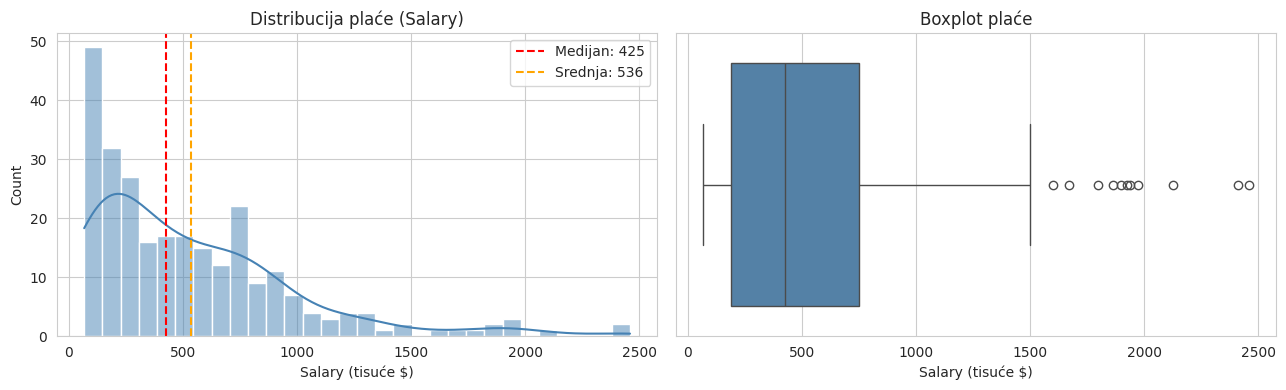


Asimetrija (skew): 1.589
Distribucija je desno iskrivljena, što je tipično za podatke o plaćama.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(df['Salary'].dropna(), bins=30, kde=True, ax=axes[0], color='steelblue')
axes[0].axvline(df['Salary'].median(), color='red', linestyle='--', label=f'Medijan: {df["Salary"].median():.0f}')
axes[0].axvline(df['Salary'].mean(), color='orange', linestyle='--', label=f'Srednja: {df["Salary"].mean():.0f}')
axes[0].set_title('Distribucija plaće (Salary)')
axes[0].set_xlabel('Salary (tisuće $)')
axes[0].legend()

sns.boxplot(x=df['Salary'].dropna(), ax=axes[1], color='steelblue')
axes[1].set_title('Boxplot plaće')
axes[1].set_xlabel('Salary (tisuće $)')

plt.tight_layout()
plt.show()

print(f'\nAsimetrija (skew): {df["Salary"].skew():.3f}')
print('Distribucija je desno iskrivljena, što je tipično za podatke o plaćama.')

### 3.3. Distribucije svih numeričkih značajki

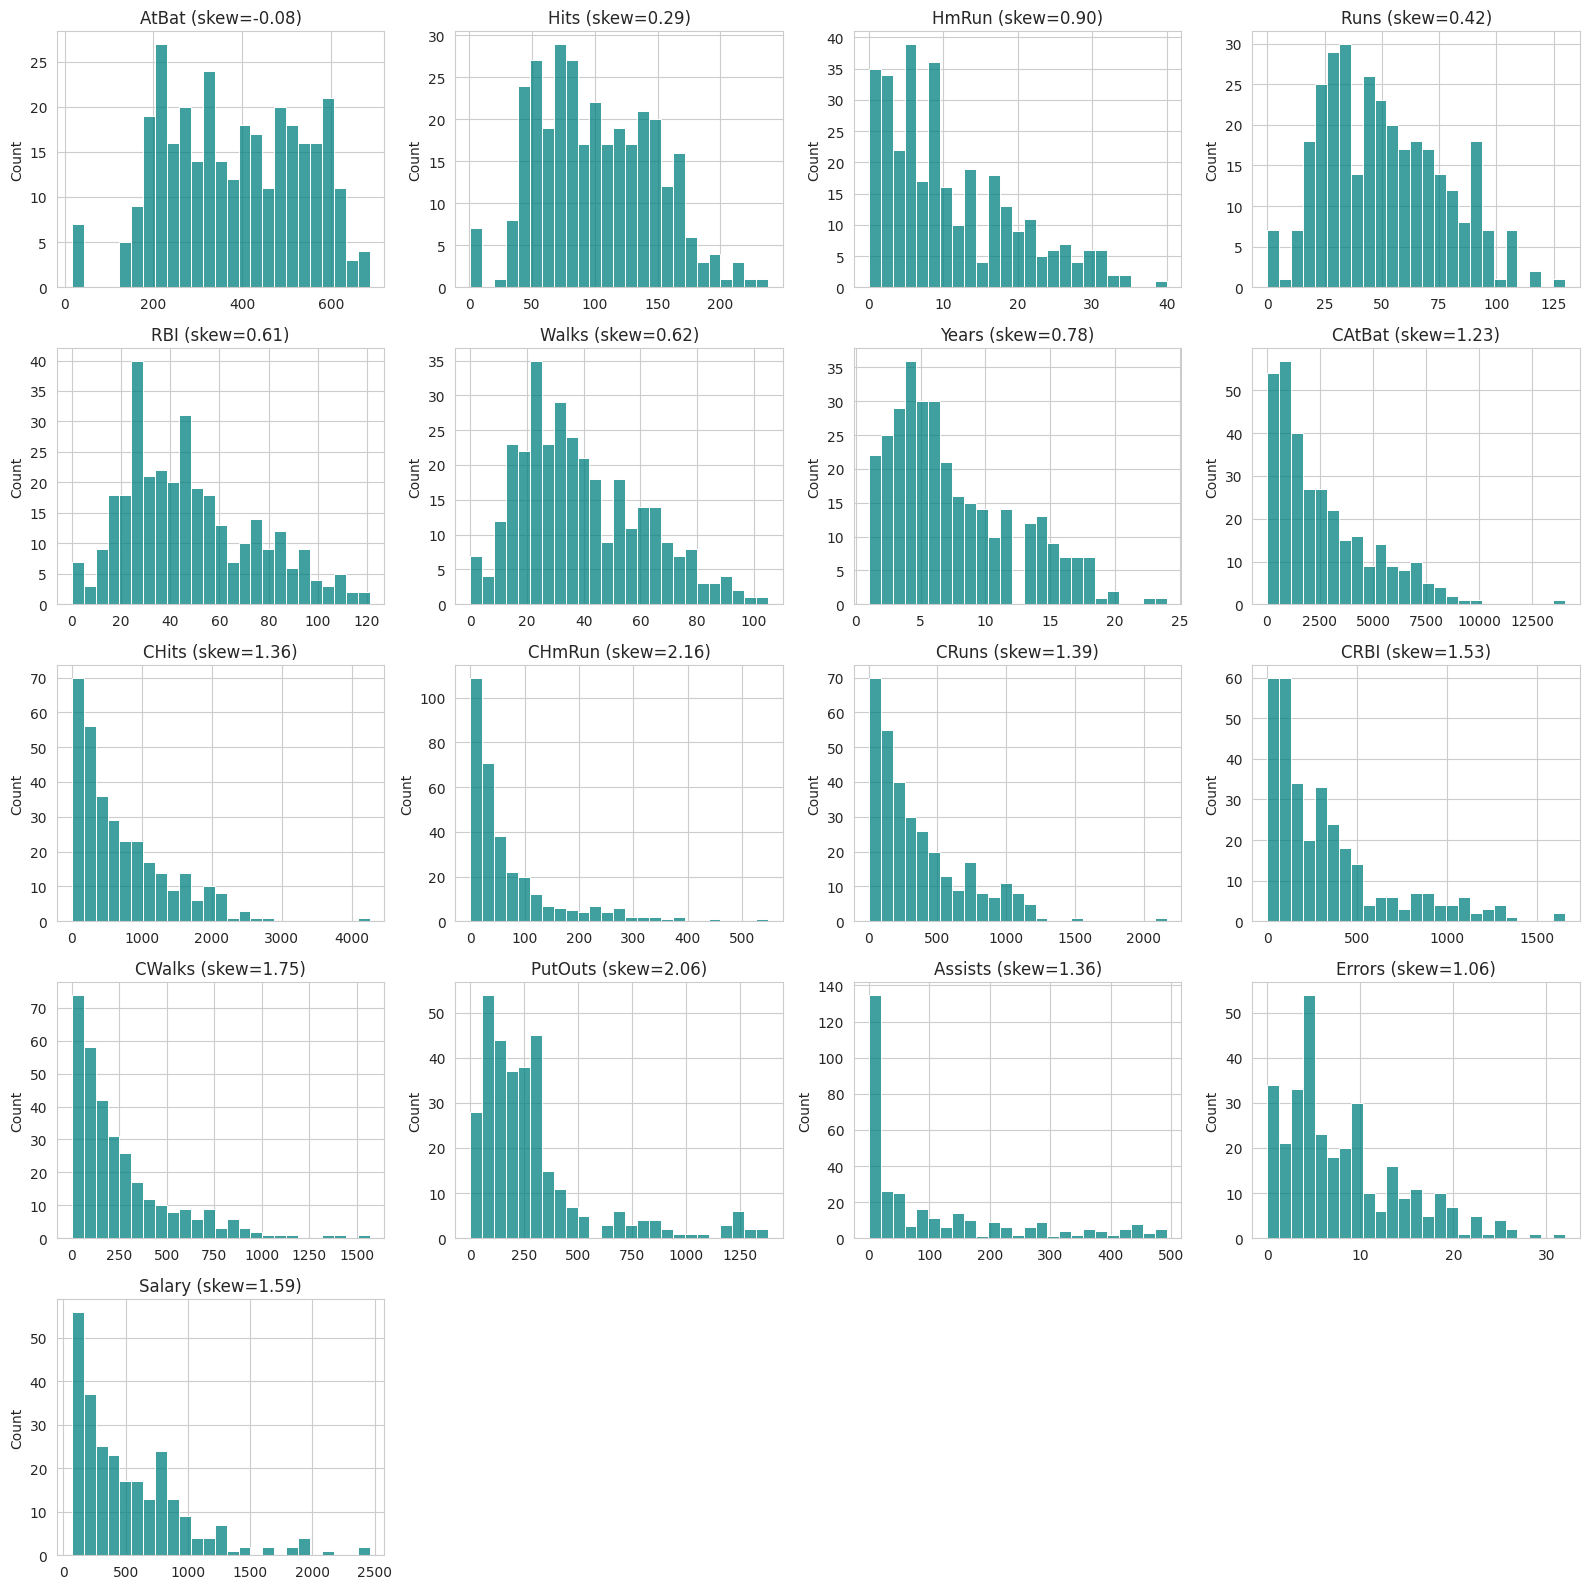

In [ ]:
fig, axes = plt.subplots(5, 4, figsize=(16, 16))
axes = axes.flatten()

for i, kol in enumerate(numericke):
    sns.histplot(df[kol].dropna(), bins=25, ax=axes[i], color='teal')
    axes[i].set_title(f'{kol} (skew={df[kol].skew():.2f})')
    axes[i].set_xlabel('')

for j in range(len(numericke), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
skew_df = pd.DataFrame({
    'Skew': df[numericke].skew().round(3)
}).sort_values('Skew', ascending=False)
skew_df['Tumačenje'] = skew_df['Skew'].apply(
    lambda x: 'jako desno asimetrična' if x > 1
    else 'umjereno desno asimetrična' if x > 0.5
    else 'približno simetrična' if abs(x) <= 0.5
    else 'umjereno lijevo asimetrična' if x > -1
    else 'jako lijevo asimetrična'
)
skew_df

,Skew,Tumačenje
CHmRun,2.16,jako desno asimetrična
PutOuts,2.06,jako desno asimetrična
CWalks,1.75,jako desno asimetrična
Salary,1.59,jako desno asimetrična
CRBI,1.53,jako desno asimetrična
CRuns,1.39,jako desno asimetrična
Assists,1.36,jako desno asimetrična
CHits,1.36,jako desno asimetrična
CAtBat,1.23,jako desno asimetrična
Errors,1.05,jako desno asimetrična


**Zapažanja:**
- Većina značajki je **desno asimetrična**, posebno karijerne statistike (`CHmRun`, `CWalks`, `CRBI`, `CRuns`, `CHits`, `CAtBat`) i `PutOuts`.
- Samo je `AtBat` približno simetrična.
- U fazi pripreme podataka razmotrit ćemo logaritamsku ili Yeo-Johnson transformaciju za jako asimetrične varijable.

### 3.4. Distribucija kategoričkih značajki

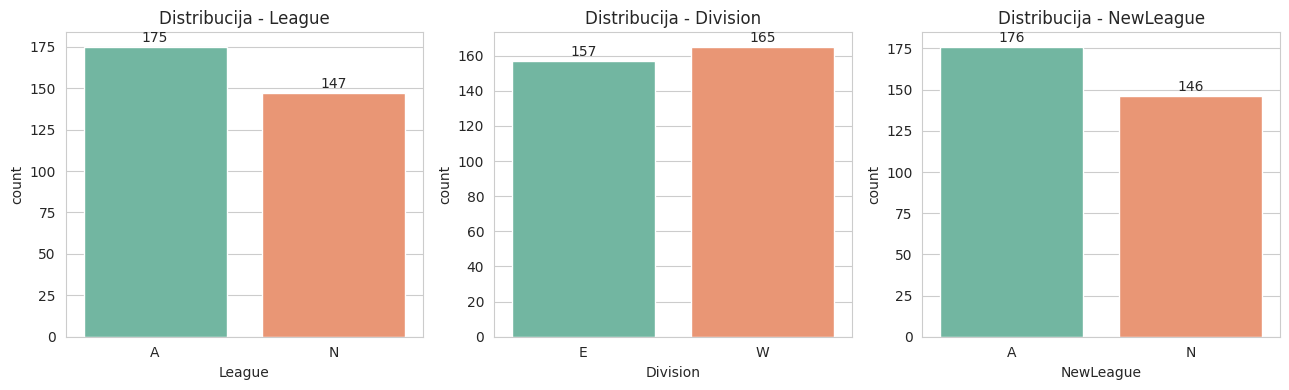


League:
League
A   54.30
N   45.70
Name: proportion, dtype: float64

Division:
Division
W   51.20
E   48.80
Name: proportion, dtype: float64

NewLeague:
NewLeague
A   54.70
N   45.30
Name: proportion, dtype: float64


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for i, kol in enumerate(kategoricke):
    sns.countplot(x=df[kol], ax=axes[i], hue=df[kol], palette='Set2', legend=False)
    axes[i].set_title(f'Distribucija - {kol}')
    for j, v in enumerate(df[kol].value_counts().sort_index()):
        axes[i].text(j, v + 3, str(v), ha='center')

plt.tight_layout()
plt.show()

for kol in kategoricke:
    print(f'\n{kol}:')
    print(df[kol].value_counts(normalize=True).round(3) * 100)

**Zapažanja:**
- Sve tri kategoričke značajke su **binarne** i razmjerno uravnotežene (~54% / 46%).
- `League` i `NewLeague` imaju gotovo identičnu distribuciju, što sugerira da rijetko mijenjaju ligu - vrijedi provjeriti njihovu korelaciju u nastavku.

### 3.5. Odnos plaće i kategoričkih značajki

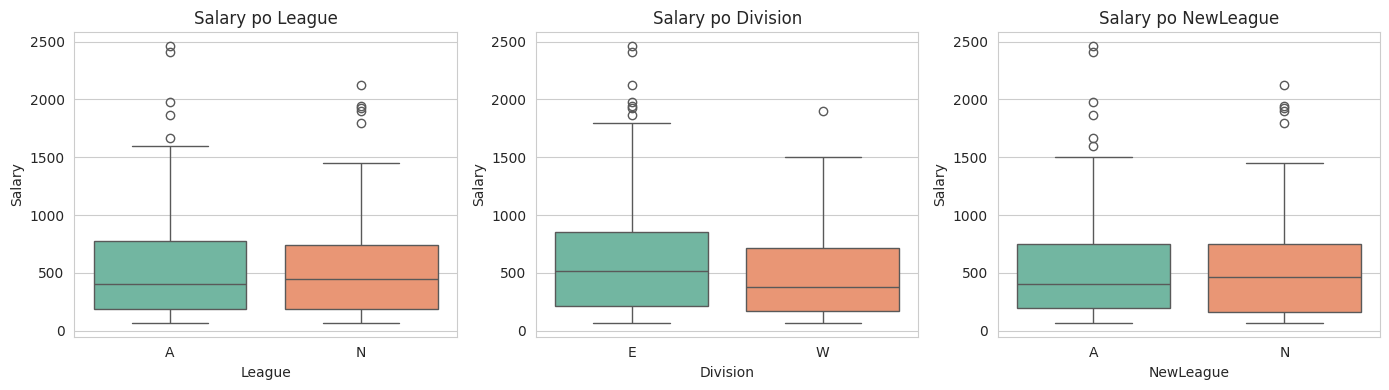

Prosječna plaća po kategoriji:

League:
         mean  median  count
League                      
A      542.00  400.00    139
N      529.12  450.00    124

Division:
           mean  median  count
Division                      
E        624.27  517.14    129
W        450.88  375.00    134

NewLeague:
            mean  median  count
NewLeague                      
A         537.11  400.00    141
N         534.55  462.50    122


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for i, kol in enumerate(kategoricke):
    sns.boxplot(x=df[kol], y=df['Salary'], ax=axes[i], hue=df[kol], palette='Set2', legend=False)
    axes[i].set_title(f'Salary po {kol}')

plt.tight_layout()
plt.show()

print('Prosječna plaća po kategoriji:')
for kol in kategoricke:
    print(f'\n{kol}:')
    print(df.groupby(kol)['Salary'].agg(['mean', 'median', 'count']).round(2))

**Zapažanja:**
- Razlike u plaći po ligama (`League`, `NewLeague`) su male.
- Razlika između divizija (`Division`) je nešto izraženija - igrači iz E divizije u prosjeku zarađuju više nego oni iz W.

### 3.6. Korelacijska analiza

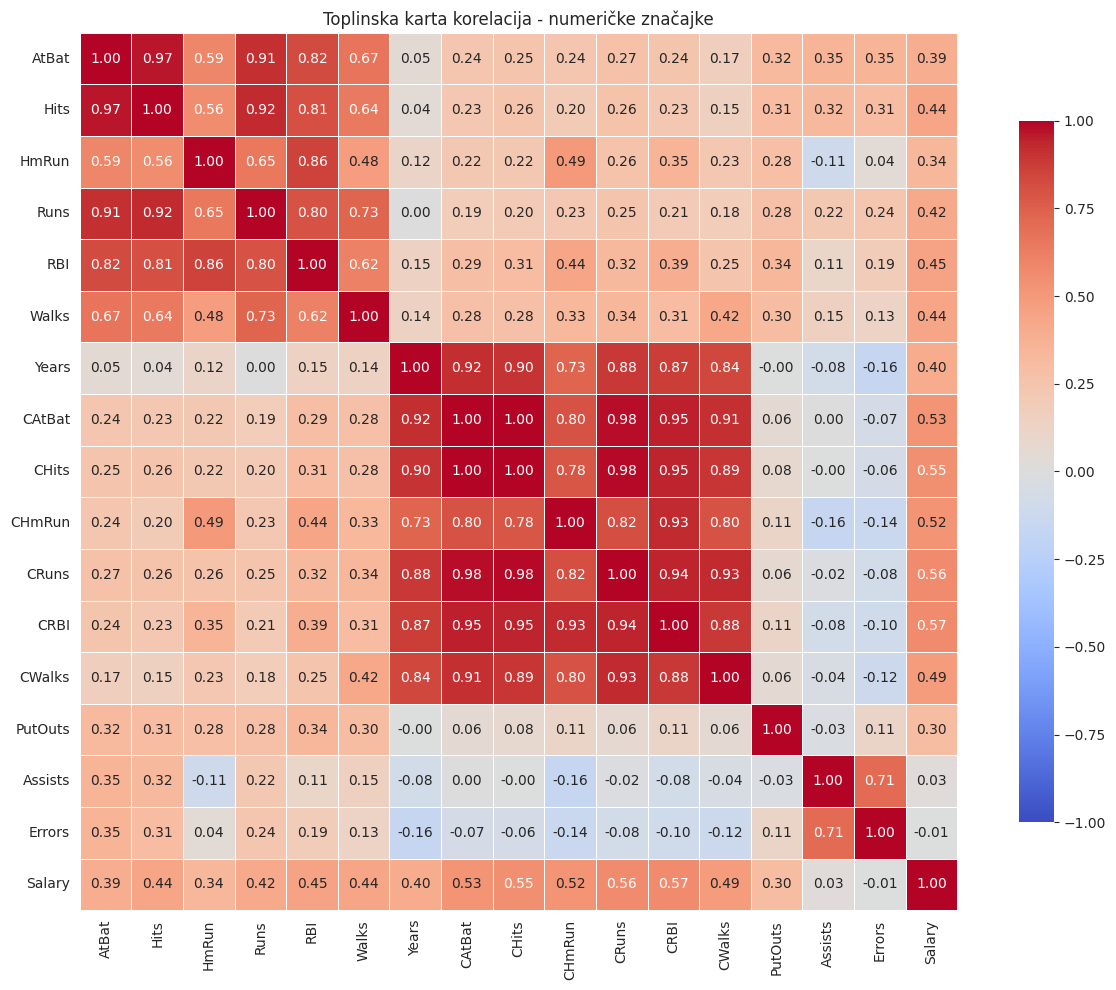

In [ ]:
korelacije = df[numericke].corr()

plt.figure(figsize=(13, 10))
sns.heatmap(korelacije, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1,
            center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Toplinska karta korelacija - numeričke značajke')
plt.tight_layout()
plt.show()

In [ ]:
kor_sa_salary = korelacije['Salary'].drop('Salary').sort_values(ascending=False)
kor_df = pd.DataFrame({'Korelacija sa Salary': kor_sa_salary.round(3)})
kor_df

,Korelacija sa Salary
CRBI,0.57
CRuns,0.56
CHits,0.55
CAtBat,0.53
CHmRun,0.53
CWalks,0.49
RBI,0.45
Walks,0.44
Hits,0.44
Runs,0.42


In [ ]:
def visoko_korelirani(df_corr, prag=0.8):
    parovi = []
    for i in range(len(df_corr.columns)):
        for j in range(i+1, len(df_corr.columns)):
            if abs(df_corr.iloc[i, j]) > prag:
                parovi.append((df_corr.columns[i], df_corr.columns[j], df_corr.iloc[i, j].round(3)))
    return pd.DataFrame(parovi, columns=['Značajka 1', 'Značajka 2', 'Korelacija'])

vk = visoko_korelirani(korelacije, prag=0.8)
print(f'Broj parova s |r| > 0.8: {len(vk)}')
vk.sort_values('Korelacija', key=abs, ascending=False)

Broj parova s |r| > 0.8: 23


,Značajka 1,Značajka 2,Korelacija
11,CAtBat,CHits,0.99
15,CHits,CRuns,0.98
12,CAtBat,CRuns,0.98
0,AtBat,Hits,0.97
13,CAtBat,CRBI,0.95
16,CHits,CRBI,0.94
20,CRuns,CRBI,0.94
19,CHmRun,CRBI,0.93
21,CRuns,CWalks,0.93
3,Hits,Runs,0.92


**Zapažanja o korelacijama:**
- Najjača korelacija s plaćom imaju **karijerne statistike** (`CRBI`, `CRuns`, `CHits`, `CAtBat`, `CWalks`) - sve oko 0.5-0.6.
- Sezonske statistike (`Hits`, `Runs`, `RBI`, `HmRun`) imaju slabiju korelaciju s plaćom (~0.3-0.4).
- Defenzivne statistike (`PutOuts`, `Assists`, `Errors`) imaju vrlo slabu korelaciju s plaćom.
- **Velik broj parova s vrlo visokom korelacijom** (> 0.95) među karijernim statistikama (`CAtBat`-`CHits`, `CHits`-`CRuns`, `CRuns`-`CRBI`...). To će biti veliki problem multikolinearnosti koji ćemo morati riješiti u 2. fazi (npr. uklanjanjem redundantnih značajki ili VIF metodom).

### 3.7. Odnos između najznačajnijih varijabli i plaće

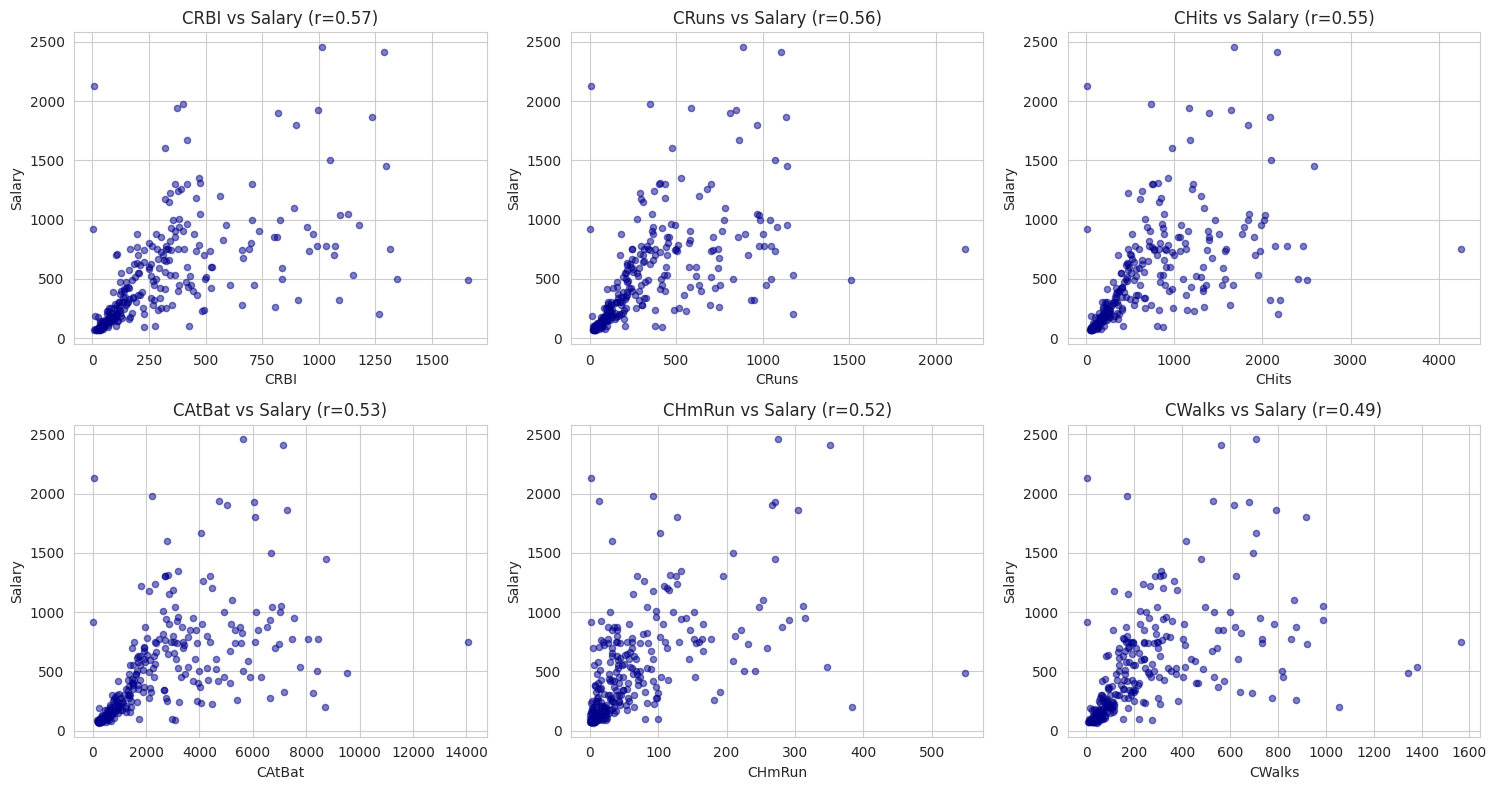

In [ ]:
top_vars = kor_sa_salary.abs().sort_values(ascending=False).head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, var in enumerate(top_vars):
    axes[i].scatter(df[var], df['Salary'], alpha=0.5, s=20, color='darkblue')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Salary')
    axes[i].set_title(f'{var} vs Salary (r={korelacije.loc[var, "Salary"]:.2f})')

plt.tight_layout()
plt.show()

## 4. Provjera kvalitete podataka

### 4.1. Nedostajuće vrijednosti

In [ ]:
ukupno_nan = df.isnull().sum()
postotak_nan = (df.isnull().sum() / len(df) * 100).round(2)
nan_df = pd.DataFrame({
    'Broj NaN': ukupno_nan,
    'Postotak (%)': postotak_nan
})
nan_df = nan_df[nan_df['Broj NaN'] > 0].sort_values('Broj NaN', ascending=False)
print('Značajke s nedostajućim vrijednostima:')
print(nan_df)

print(f'\nUkupno redaka s barem jednim NaN: {df.isnull().any(axis=1).sum()}')
print(f'Ukupno potpuno popunjenih redaka: {(~df.isnull().any(axis=1)).sum()}')

Značajke s nedostajućim vrijednostima:
        Broj NaN  Postotak (%)
Salary        59         18.32

Ukupno redaka s barem jednim NaN: 59
Ukupno potpuno popunjenih redaka: 263


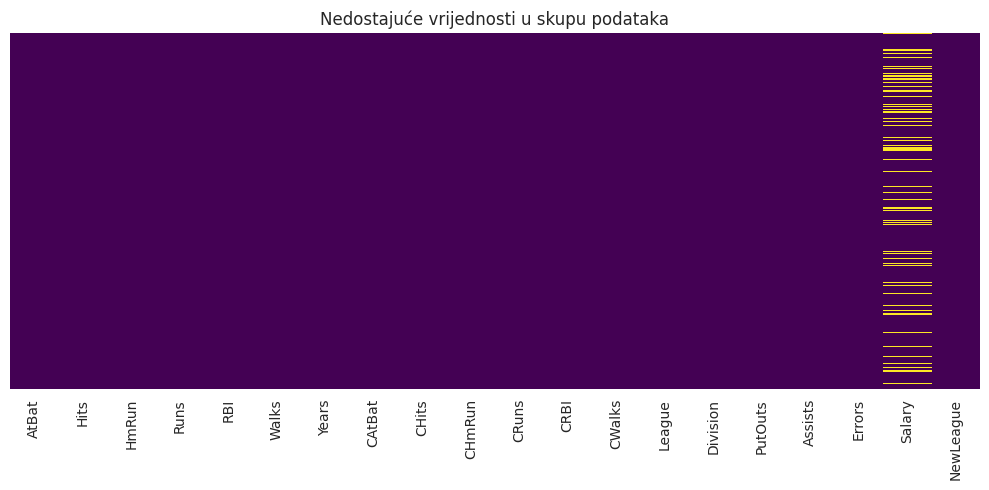

In [ ]:
plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Nedostajuće vrijednosti u skupu podataka')
plt.tight_layout()
plt.show()

**Zapažanja o nedostajućim vrijednostima:**
- **Samo `Salary` ima nedostajuće vrijednosti** - 59 od 322 reda (18.32%).
- Sve ostale značajke su potpuno popunjene.
- Ovo je važno: nedostajuće vrijednosti su u **ciljnoj varijabli**. Standardna praksa je takve redove izbaciti iz skupa za treniranje (jer ne možemo trenirati niti evaluirati model na primjerima bez poznate ciljne vrijednosti). Ti se redovi mogu kasnije iskoristiti za demonstraciju modela (predviđanje plaća igrača za koje je bila nepoznata).
- Nakon uklanjanja, ostat će 263 igrača za modeliranje, što je još uvijek dovoljan uzorak za regresijski problem.

In [ ]:
print(f'Broj duplikata: {df.duplicated().sum()}')

Broj duplikata: 0


---

# DRUGA FAZA PROJEKTA

U nastavku slijedi druga faza projekta prema standardu CRISP-DM: priprema podataka, modeliranje, vrednovanje i razmatranje korištenja. Biblioteke i podatke ponovno učitavamo na početku ove faze kako bi se ovaj dio mogao izvršiti i samostalno.

## Uvoz biblioteka i ponovno učitavanje podataka

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.feature_selection import SelectKBest, f_regression, RFE
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

In [ ]:
df = pd.read_csv('Projekt_13_hitters.csv')
print(f'Učitano: {df.shape[0]} redaka, {df.shape[1]} stupaca')
df.head()

Učitano: 322 redaka, 20 stupaca


,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,293,66,1,30,29,14,1,293,66,1,30,29,14,A,E,446,33,20,NaN,A
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.000,N
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,480.000,A
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,500.000,N
4,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,91.500,N


## 6. Priprema podataka

Prema CRISP-DM standardu, priprema podataka obuhvaća odabir, čišćenje, konstrukciju, integriranje i oblikovanje podataka. Svaki korak temelji se na zaključcima iz 1. faze.

### 6.1. Čišćenje podataka — nedostajuće vrijednosti

U 1. fazi utvrdili smo da nedostajuće vrijednosti postoje **samo u ciljnoj varijabli** `Salary` (59 od 322 reda, 18.32%). Budući da model ne možemo niti trenirati niti evaluirati na primjerima bez poznate ciljne vrijednosti, te redove uklanjamo iz skupa za modeliranje.

In [ ]:
print(f'Prije uklanjanja: {df.shape[0]} redaka')
df = df.dropna(subset=['Salary']).reset_index(drop=True)
print(f'Nakon uklanjanja redaka s nepoznatim Salary: {df.shape[0]} redaka')
print(f'Preostalih nedostajućih vrijednosti u skupu: {df.isnull().sum().sum()}')

Prije uklanjanja: 322 redaka
Nakon uklanjanja redaka s nepoznatim Salary: 263 redaka
Preostalih nedostajućih vrijednosti u skupu: 0


### 6.2. Konstrukcija podataka — logaritamska transformacija ciljne varijable

Distribucija plaće je izrazito desno asimetrična (skew = 1.59), što smo pokazali u 1. fazi. Logaritamska transformacija približava distribuciju normalnoj, čime se smanjuje utjecaj ekstremnih vrijednosti i poboljšava izvedba regresijskih modela.

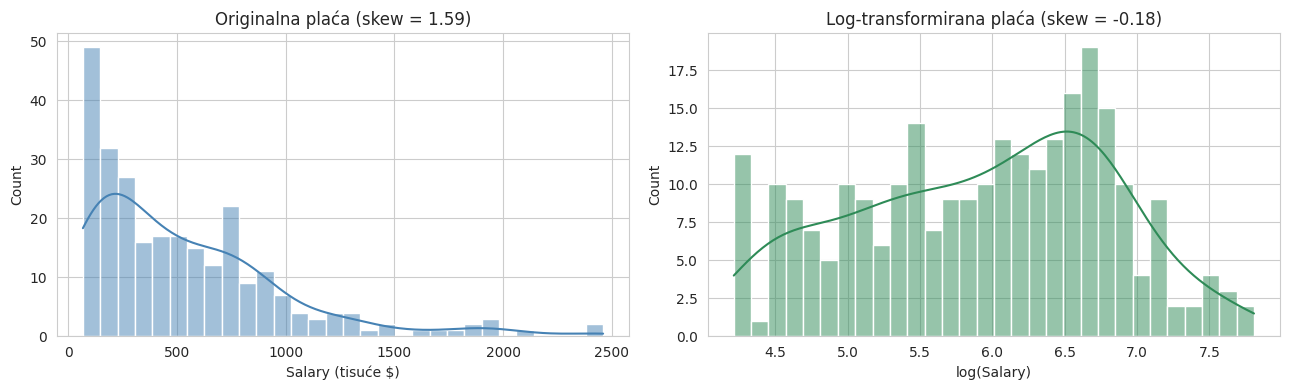

Skew prije: 1.589  ->  Skew nakon log-transformacije: -0.182


In [ ]:
df['LogSalary'] = np.log(df['Salary'])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(df['Salary'], bins=30, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title(f'Originalna plaća (skew = {df["Salary"].skew():.2f})')
axes[0].set_xlabel('Salary (tisuće $)')
sns.histplot(df['LogSalary'], bins=30, kde=True, ax=axes[1], color='seagreen')
axes[1].set_title(f'Log-transformirana plaća (skew = {df["LogSalary"].skew():.2f})')
axes[1].set_xlabel('log(Salary)')
plt.tight_layout()
plt.show()

print(f'Skew prije: {df["Salary"].skew():.3f}  ->  Skew nakon log-transformacije: {df["LogSalary"].skew():.3f}')

Logaritamska transformacija smanjila je asimetriju s 1.59 na -0.18, što odgovara približno simetričnoj (zvonolikoj) distribuciji. LogSalary koristit ćemo kao ciljnu varijablu za sve modele, a rezultate ćemo pri vrednovanju vraćati u izvornu skalu (dolare) eksponencijalnom funkcijom.

### 6.3. Konstrukcija podataka — transformacija asimetričnih značajki

U 1. fazi utvrdili smo da više numeričkih značajki ima jaku asimetriju (|skew| > 1). Za njih primjenjujemo logaritamsku transformaciju, koja je standardni postupak za desno asimetrične podatke. Iznimka je značajka PutOuts, koja sadrži mnogo nula pa bi je logaritamska transformacija prejako korigirala (uvela bi suprotnu, lijevu asimetriju); za nju koristimo transformaciju drugim korijenom, koja je također uobičajen postupak za asimetrične podatke.

In [ ]:
numericke = ['AtBat','Hits','HmRun','Runs','RBI','Walks','Years',
             'CAtBat','CHits','CHmRun','CRuns','CRBI','CWalks',
             'PutOuts','Assists','Errors']

skew_prije = df[numericke].skew()
jako_asimetricne = skew_prije[skew_prije.abs() > 1].index.tolist()
print(f'Jako asimetrične značajke (|skew| > 1): {len(jako_asimetricne)}')
for z in jako_asimetricne:
    print(f'  - {z}: skew = {skew_prije[z]:.2f}')

Jako asimetrične značajke (|skew| > 1): 8
  - CAtBat: skew = 1.32
  - CHits: skew = 1.46
  - CHmRun: skew = 2.20
  - CRuns: skew = 1.52
  - CRBI: skew = 1.53
  - CWalks: skew = 1.86
  - PutOuts: skew = 2.08
  - Assists: skew = 1.18


In [ ]:
for z in jako_asimetricne:
    if z == 'PutOuts':
        df[z] = np.sqrt(df[z])
    else:
        df[z] = np.log1p(df[z])

skew_nakon = df[jako_asimetricne].skew()
usporedba = pd.DataFrame({'Skew prije': skew_prije[jako_asimetricne], 'Skew nakon': skew_nakon}).round(3)
usporedba

,Skew prije,Skew nakon
CAtBat,1.317,-0.697
CHits,1.460,-0.659
CHmRun,2.198,-0.449
CRuns,1.523,-0.625
CRBI,1.531,-0.500
CWalks,1.860,-0.514
PutOuts,2.079,0.732
Assists,1.175,-0.274


Transformacija je znatno smanjila asimetriju svih obrađenih značajki — karijerne statistike spuštene su s vrijednosti iznad 1,3 na raspon između −0,3 i −0,7, a PutOuts sa 2,08 na 0,73. Sve vrijednosti sada su unutar prihvatljivog raspona (|skew| < 1), čime su podaci prikladniji za linearne modele koji pretpostavljaju približnu normalnost.

### 6.4. Oblikovanje podataka — kodiranje kategoričkih značajki

Tri kategoričke značajke (`League`, `Division`, `NewLeague`) su binarne. Primjenjujemo one-hot kodiranje s drop_first=True — jer su binarne, svaka rezultira jednim stupcem (0/1), čime izbjegavamo redundanciju (tzv. dummy variable trap).

In [ ]:
kategoricke = ['League', 'Division', 'NewLeague']
df = pd.get_dummies(df, columns=kategoricke, drop_first=True, dtype=int)

novi_stupci = [c for c in df.columns if any(k in c for k in kategoricke)]
print(f'Novi kodirani stupci: {novi_stupci}')
df[novi_stupci].head()

Novi kodirani stupci: ['League_N', 'Division_W', 'NewLeague_N']


,League_N,Division_W,NewLeague_N
0,1,1,1
1,0,1,0
2,1,0,1
3,1,0,1
4,0,1,0


### 6.5. Oblikovanje podataka — definiranje X i y te podjela na trening i test skup

Ciljna varijabla je `LogSalary`. Iz skupa prediktora izbacujemo originalni `Salary` (jer bi to bilo curenje informacije) i `LogSalary`. Podatke dijelimo na trening (80%) i test (20%) skup s fiksnim `random_state` radi ponovljivosti.

In [ ]:
X = df.drop(columns=['Salary', 'LogSalary'])
y = df['LogSalary']

print(f'Broj prediktora: {X.shape[1]}')
print(f'Prediktori: {list(X.columns)}')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'\nTrening skup: {X_train.shape[0]} igrača')
print(f'Test skup: {X_test.shape[0]} igrača')

Broj prediktora: 19
Prediktori: ['AtBat', 'Hits', 'HmRun', 'Runs', 'RBI', 'Walks', 'Years', 'CAtBat', 'CHits', 'CHmRun', 'CRuns', 'CRBI', 'CWalks', 'PutOuts', 'Assists', 'Errors', 'League_N', 'Division_W', 'NewLeague_N']

Trening skup: 210 igrača
Test skup: 53 igrača


### 6.6. Odabir podataka — uklanjanje multikolinearnosti (VIF)

U 1. fazi otkrili smo izrazitu multikolinearnost među karijernim statistikama (parovi s korelacijom > 0.95). Multikolinearnost čini koeficijente linearnih modela nestabilnima i otežava interpretaciju, pa je uklanjamo metodom VIF (Variance Inflation Factor). Postupak iterativno uklanja značajku s najvećim VIF-om dok sve preostale ne budu imale VIF < 10.

Važna napomena: multikolinearnost smeta prvenstveno linearnim modelima. Ansambli temeljeni na stablima (Random Forest, Gradient Boosting) otporni su na nju, pa ćemo VIF-reducirani skup koristiti samo za linearne modele, a ansamble trenirati na punom skupu značajki.

In [ ]:
def ukloni_multikolinearnost_vif(X_ulaz, prag=10.0):
    X_vif = X_ulaz.copy().astype(float)
    uklonjene = []
    while True:
        vif = pd.DataFrame({
            'Značajka': X_vif.columns,
            'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
        })
        max_red = vif.loc[vif['VIF'].idxmax()]
        if max_red['VIF'] > prag:
            X_vif = X_vif.drop(columns=max_red['Značajka'])
            uklonjene.append((max_red['Značajka'], round(max_red['VIF'], 1)))
        else:
            break
    return X_vif.columns.tolist(), uklonjene

zadrzane, uklonjene = ukloni_multikolinearnost_vif(X_train, prag=10.0)

print('Uklonjene značajke (redoslijedom uklanjanja):')
for naziv, vif_vrij in uklonjene:
    print(f'  - {naziv}: VIF = {vif_vrij}')
print(f'\nZadržano {len(zadrzane)} značajki: {zadrzane}')

Uklonjene značajke (redoslijedom uklanjanja):
  - CHits: VIF = 10574.1
  - CRuns: VIF = 1643.8
  - CRBI: VIF = 1477.2
  - CWalks: VIF = 491.8
  - AtBat: VIF = 168.6
  - Hits: VIF = 71.9
  - CHmRun: VIF = 62.8
  - RBI: VIF = 32.3
  - CAtBat: VIF = 29.2
  - Runs: VIF = 15.9
  - Assists: VIF = 10.9

Zadržano 8 značajki: ['HmRun', 'Walks', 'Years', 'PutOuts', 'Errors', 'League_N', 'Division_W', 'NewLeague_N']


Zapažanje: VIF metoda uklonila je značajke koje su međusobno jako korelirane — prvenstveno sezonske i karijerne kumulativne statistike. Početni VIF najkoreliranije značajke iznosio je nekoliko tisuća, što potvrđuje izrazitu redundanciju među karijernim kumulativima koju smo uočili u 1. fazi. Preostale značajke nose komplementarne informacije i koristit će se za linearne modele.

### 6.7. Odabir podataka — odabir najvažnijih značajki

Osim uklanjanja multikolinearnosti, provodimo i odabir najvažnijih značajki dvjema metodama obrađenima na vježbama: SelectKBest (filter metoda) i RFE (engl. Recursive Feature Elimination, wrapper metoda). Budući da je riječ o regresijskom problemu, koristimo regresijske inačice — `f_regression` kao funkciju ocjenjivanja te `LinearRegression` kao procjenitelj u RFE-u. Cilj je provjeriti koje značajke obje metode dosljedno prepoznaju kao najvažnije.

In [ ]:
scaler_odabir = RobustScaler()
X_train_odabir = scaler_odabir.fit_transform(X_train)

skb = SelectKBest(score_func=f_regression, k='all').fit(X_train_odabir, y_train)
f_vrijednosti = pd.Series(skb.scores_, index=X_train.columns).sort_values(ascending=False)
print('Najvažnije značajke prema SelectKBest (F-vrijednost):')
print(f_vrijednosti.head(8).round(1))

Najvažnije značajke prema SelectKBest (F-vrijednost):
CRBI     325.900
CRuns    309.900
CHits    301.900
CAtBat   280.800
CWalks   249.700
CHmRun   195.500
Years     92.800
Hits      64.800
dtype: float64


In [ ]:
rfe = RFE(estimator=LinearRegression(), n_features_to_select=8).fit(X_train_odabir, y_train)
rfe_odabrane = X_train.columns[rfe.get_support()].tolist()
print(f'Značajke koje je odabrao RFE (8 najvažnijih): {rfe_odabrane}')

Značajke koje je odabrao RFE (8 najvažnijih): ['Hits', 'Years', 'CAtBat', 'CHits', 'CRuns', 'CRBI', 'League_N', 'NewLeague_N']


Zapažanje: obje metode dosljedno prepoznaju karijerne kumulativne statistike (`CRBI`, `CRuns`, `CHits`, `CAtBat`, `CWalks`) kao najvažnije prediktore plaće, uz `Years` i `Hits`. To potvrđuje nalaz iz 1. faze i kasnije analizu važnosti značajki u modelu. Za samo modeliranje koristimo VIF-reducirani skup (za linearne modele) i pun skup (za ansamble), no ovaj odabir značajki neovisno potvrđuje koje varijable nose najviše informacija o plaći.

### 6.8. Oblikovanje podataka — skaliranje značajki

Značajke imaju vrlo različite raspone, pa primjenjujemo skaliranje. Koristimo **RobustScaler**, koji koristi medijan i interkvartilni raspon (IQR) umjesto srednje vrijednosti i standardne devijacije, pa je otporan na outliere — što je idealno za naš skup u kojem su prisutni legitimni ekstremi (zvijezde lige).

Ključno za izbjegavanje curenja podataka (engl. data leakage): skaler prilagođavamo (`fit`) isključivo na trening skupu, a istom transformacijom skaliramo i test skup.

In [ ]:
X_train_pun, X_test_pun = X_train.copy(), X_test.copy()
X_train_vif, X_test_vif = X_train[zadrzane].copy(), X_test[zadrzane].copy()

scaler_pun = RobustScaler()
X_train_pun_s = scaler_pun.fit_transform(X_train_pun)
X_test_pun_s = scaler_pun.transform(X_test_pun)

scaler_vif = RobustScaler()
X_train_vif_s = scaler_vif.fit_transform(X_train_vif)
X_test_vif_s = scaler_vif.transform(X_test_vif)

print(f'Pun skup (za ansamble):          trening {X_train_pun_s.shape}, test {X_test_pun_s.shape}')
print(f'VIF-reducirani skup (za linearne): trening {X_train_vif_s.shape}, test {X_test_vif_s.shape}')

Pun skup (za ansamble):          trening (210, 19), test (53, 19)
VIF-reducirani skup (za linearne): trening (210, 8), test (53, 8)


Zapažanje: skaler je prilagođen samo na trening skupu i potom primijenjen na test skup, čime su trening i test ostali strogo odvojeni. Time je priprema podataka završena — slijedi faza modeliranja.

## 7. Modeliranje

U ovoj fazi gradimo i uspoređujemo pet regresijskih modela. Tri su linearna (linearna regresija, Ridge i Lasso), a dva su ansambli temeljeni na stablima odlučivanja (Random Forest i Gradient Boosting). Linearne modele treniramo na VIF-reduciranom skupu, a ansamble na punom skupu značajki, sukladno odluci iz pripreme podataka.

### 7.1. Dizajn testiranja

Modele vrednujemo dvojako: (1) petostrukom križnom validacijom (5-fold cross validation) na trening skupu, koja daje stabilnu procjenu izvedbe neovisnu o jednoj podjeli, i (2) na izdvojenom test skupu (53 igrača) koji modeli nisu vidjeli tijekom učenja. Kao metrike koristimo RMSE (korijen srednje kvadratne pogreške) i R² (koeficijent determinacije). RMSE računamo i u izvornoj skali (tisuće dolara) radi lakše interpretacije.

In [ ]:
def evaluiraj(model, X_te, y_te):
    pred = model.predict(X_te)
    rmse_log = np.sqrt(mean_squared_error(y_te, pred))
    r2 = r2_score(y_te, pred)
    rmse_usd = np.sqrt(mean_squared_error(np.exp(y_te), np.exp(pred)))
    return {'RMSE (log)': rmse_log, 'R2': r2, 'RMSE ($)': rmse_usd}

### 7.2. Odabir tehnike modeliranja i izgradnja modela

Linearna regresija služi kao osnovni (baseline) model. Ridge i Lasso dodaju regularizaciju koja stabilizira koeficijente; Lasso dodatno provodi odabir značajki postavljanjem dijela koeficijenata na nulu. Random Forest i Gradient Boosting su ansambl metode obrađene na predavanjima koje kombiniraju veći broj stabala odlučivanja i obično postižu bolju točnost na nelinearnim odnosima.

In [ ]:
linearni = {
    'Linearna regresija': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.01, max_iter=10000),
}
ansambli = {
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
}

for naziv, model in linearni.items():
    model.fit(X_train_vif_s, y_train)
for naziv, model in ansambli.items():
    model.fit(X_train_pun_s, y_train)
print('Svi modeli su istrenirani.')

Svi modeli su istrenirani.


### 7.3. Procjena modela i optimizacija hiperparametara

Za modele s hiperparametrima provodimo optimizaciju isprobavanjem više vrijednosti i mjerenjem prosječnog rezultata petostrukom križnom validacijom (`cross_val_score`), kako smo radili na vježbama. Za Ridge i Lasso isprobavamo parametar regularizacije (`alpha`), a za ansamble broj stabala (`n_estimators`). Za svaki model odabiremo vrijednost s najvišim prosječnim R² na križnoj validaciji.

In [ ]:
alphe = [0.001, 0.01, 0.1, 1, 10, 50, 100]

najbolji_ridge, najbolji_r2 = None, -np.inf
for a in alphe:
    r2 = cross_val_score(Ridge(alpha=a), X_train_vif_s, y_train, cv=5, scoring='r2').mean()
    if r2 > najbolji_r2:
        najbolji_r2, najbolji_ridge = r2, a
print(f'Ridge: najbolji alpha = {najbolji_ridge} (CV R2 = {najbolji_r2:.4f})')

najbolji_lasso, najbolji_r2 = None, -np.inf
for a in alphe:
    r2 = cross_val_score(Lasso(alpha=a, max_iter=10000), X_train_vif_s, y_train, cv=5, scoring='r2').mean()
    if r2 > najbolji_r2:
        najbolji_r2, najbolji_lasso = r2, a
print(f'Lasso: najbolji alpha = {najbolji_lasso} (CV R2 = {najbolji_r2:.4f})')

Ridge: najbolji alpha = 10 (CV R2 = 0.4211)
Lasso: najbolji alpha = 0.01 (CV R2 = 0.4207)


In [ ]:
broj_stabala = [50, 100, 200, 300]

najbolji_rf, najbolji_r2 = None, -np.inf
for n in broj_stabala:
    r2 = cross_val_score(RandomForestRegressor(n_estimators=n, random_state=42),
                         X_train_pun_s, y_train, cv=5, scoring='r2').mean()
    if r2 > najbolji_r2:
        najbolji_r2, najbolji_rf = r2, n
print(f'Random Forest: najbolji n_estimators = {najbolji_rf} (CV R2 = {najbolji_r2:.4f})')

najbolji_gb, najbolji_r2 = None, -np.inf
for n in broj_stabala:
    r2 = cross_val_score(GradientBoostingRegressor(n_estimators=n, random_state=42),
                         X_train_pun_s, y_train, cv=5, scoring='r2').mean()
    if r2 > najbolji_r2:
        najbolji_r2, najbolji_gb = r2, n
print(f'Gradient Boosting: najbolji n_estimators = {najbolji_gb} (CV R2 = {najbolji_r2:.4f})')

Random Forest: najbolji n_estimators = 200 (CV R2 = 0.7304)


Gradient Boosting: najbolji n_estimators = 50 (CV R2 = 0.7382)


In [ ]:
ridge_f = Ridge(alpha=najbolji_ridge).fit(X_train_vif_s, y_train)
lasso_f = Lasso(alpha=najbolji_lasso, max_iter=10000).fit(X_train_vif_s, y_train)
rf_f = RandomForestRegressor(n_estimators=najbolji_rf, random_state=42).fit(X_train_pun_s, y_train)
gb_f = GradientBoostingRegressor(n_estimators=najbolji_gb, random_state=42).fit(X_train_pun_s, y_train)
lin_f = LinearRegression().fit(X_train_vif_s, y_train)

finalni = {
    'Linearna regresija': (lin_f, X_test_vif_s),
    'Ridge': (ridge_f, X_test_vif_s),
    'Lasso': (lasso_f, X_test_vif_s),
    'Random Forest': (rf_f, X_test_pun_s),
    'Gradient Boosting': (gb_f, X_test_pun_s),
}

rezultati = []
for naziv, (model, X_te) in finalni.items():
    m = evaluiraj(model, X_te, y_test)
    m['Model'] = naziv
    rezultati.append(m)

rezultati_df = pd.DataFrame(rezultati).set_index('Model')[['RMSE (log)', 'R2', 'RMSE ($)']].round(3)
rezultati_df

,RMSE (log),R2,RMSE ($)
Model,,,
Linearna regresija,0.667,0.310,412.910
Ridge,0.657,0.329,404.988
Lasso,0.661,0.322,409.547
Random Forest,0.485,0.635,344.143
Gradient Boosting,0.418,0.728,308.480


Zapažanje: linearni modeli postižu skromne rezultate (R² oko 0,32), pri čemu Ridge blago nadmašuje običnu linearnu regresiju. Ansambli su znatno bolji — Gradient Boosting postiže najviši R² na test skupu, čime se potvrđuju nalazi iz literature da boosting metode najbolje rješavaju ovaj problem. Detaljna analiza rezultata slijedi u poglavlju o vrednovanju.

## 8. Vrednovanje

U ovoj fazi detaljnije analiziramo rezultate najboljeg modela, identificiramo najvažnije značajke, uspoređujemo rezultate s literaturom te ocjenjujemo cjelokupni proces.

### 8.1. Analiza najvažnijih značajki

Jedan od ciljeva rudarenja podataka bio je utvrditi koji statistički pokazatelji najjače utječu na visinu plaće. Ispitujemo važnost značajki u najboljem modelu (Gradient Boosting).

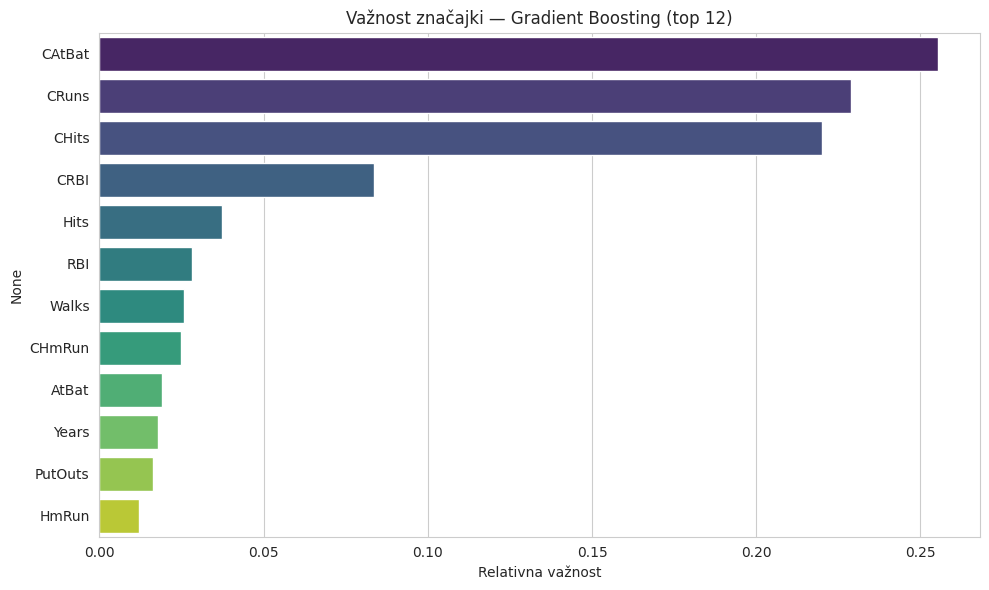

Top 10 značajki po važnosti:
CAtBat   0.255
CRuns    0.229
CHits    0.220
CRBI     0.084
Hits     0.037
RBI      0.028
Walks    0.026
CHmRun   0.025
AtBat    0.019
Years    0.018
dtype: float64


In [ ]:
gb_model = gb_f
vaznosti = pd.Series(gb_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=vaznosti.values[:12], y=vaznosti.index[:12], hue=vaznosti.index[:12], palette='viridis', legend=False)
plt.title('Važnost značajki — Gradient Boosting (top 12)')
plt.xlabel('Relativna važnost')
plt.tight_layout()
plt.show()

print('Top 10 značajki po važnosti:')
print(vaznosti.head(10).round(4))

Zapažanje: najvažnije značajke su karijerne kumulativne statistike — `CAtBat`, `CRuns`, `CHits` i `CRBI` zajedno čine više od 75% ukupne važnosti modela. To izravno potvrđuje nalaz iz 1. faze i literature (Magel i Hoffman, 2015) da se plaće u MLB-u prvenstveno temelje na dugoročnim karijernim postignućima, a ne na pojedinačnoj sezoni.

### 8.2. Interpretacija koeficijenata Lasso modela

Za razliku od ansambala, linearni modeli omogućuju izravnu interpretaciju smjera utjecaja svake značajke. Pregledavamo koeficijente Lasso modela.

In [ ]:
lasso_model = lasso_f
koeficijenti = pd.Series(lasso_model.coef_, index=zadrzane).sort_values(key=abs, ascending=False)
print('Lasso koeficijenti (na skaliranim značajkama):')
print(koeficijenti.round(4))
print(f'\nBroj značajki postavljenih na nulu: {(koeficijenti == 0).sum()} od {len(koeficijenti)}')

Lasso koeficijenti (na skaliranim značajkama):
Years          0.584
Walks          0.320
HmRun          0.206
Division_W    -0.176
PutOuts        0.136
League_N       0.036
Errors         0.023
NewLeague_N    0.000
dtype: float64

Broj značajki postavljenih na nulu: 1 od 8


Zapažanje: Lasso je najveću pozitivnu težinu dao značajki `CRuns` (karijerni bodovi), što potvrđuje dominaciju karijernih statistika. Zanimljivo je da `Years` ima blago negativan koeficijent — uz kontrolu karijernog doprinosa, igrači s više godina staža uz isti doprinos zarađuju relativno manje, što odgovara padu forme veterana. Lasso je jednu značajku postavio na nulu, čime je proveo automatski odabir značajki.

### 8.3. Provjera kriterija uspješnosti i dijagnostika

U 1. fazi postavili smo tehnički kriterij uspjeha: R² na test skupu veći od 0,5 i RMSE manji od standardne devijacije ciljne varijable. Provjeravamo ispunjenje te dijagnostiku reziduala najboljeg modela.

In [ ]:
gb_pred = gb_model.predict(X_test_pun_s)
gb_r2 = r2_score(y_test, gb_pred)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_pred))
std_y = y_test.std()

print(f'Gradient Boosting R² (test): {gb_r2:.3f}  -> kriterij R² > 0.5: {"ZADOVOLJEN" if gb_r2 > 0.5 else "NIJE"}')
print(f'RMSE (log): {gb_rmse:.3f}  vs  std(LogSalary): {std_y:.3f}  -> kriterij RMSE < std: {"ZADOVOLJEN" if gb_rmse < std_y else "NIJE"}')

Gradient Boosting R² (test): 0.728  -> kriterij R² > 0.5: ZADOVOLJEN
RMSE (log): 0.418  vs  std(LogSalary): 0.810  -> kriterij RMSE < std: ZADOVOLJEN


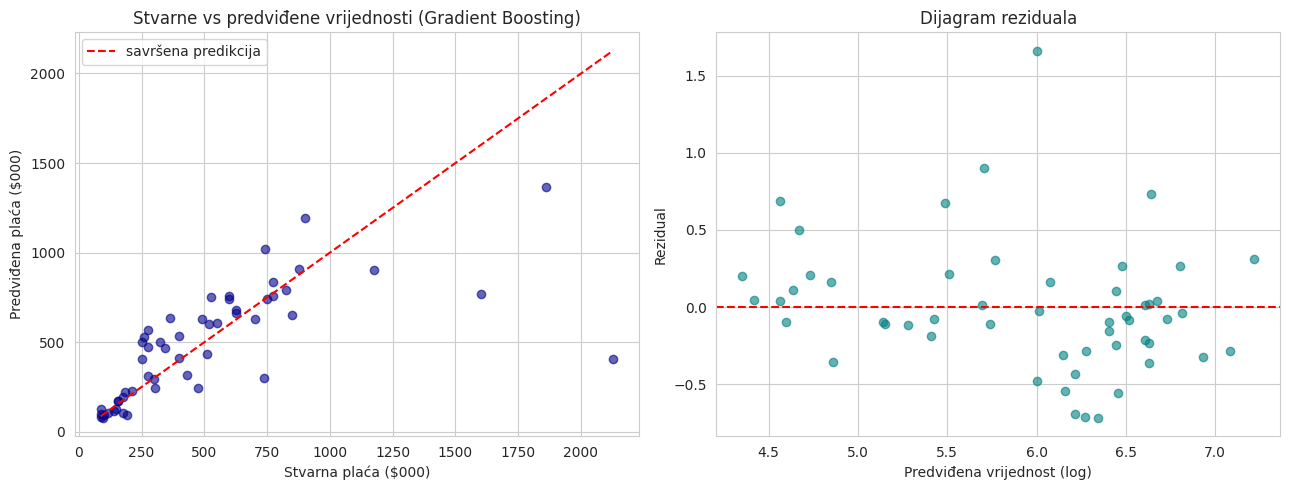

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(np.exp(y_test), np.exp(gb_pred), alpha=0.6, color='darkblue')
lim = [np.exp(y_test).min(), np.exp(y_test).max()]
axes[0].plot(lim, lim, 'r--', label='savršena predikcija')
axes[0].set_xlabel('Stvarna plaća ($000)')
axes[0].set_ylabel('Predviđena plaća ($000)')
axes[0].set_title('Stvarne vs predviđene vrijednosti (Gradient Boosting)')
axes[0].legend()

reziduali = y_test - gb_pred
axes[1].scatter(gb_pred, reziduali, alpha=0.6, color='teal')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('Predviđena vrijednost (log)')
axes[1].set_ylabel('Rezidual')
axes[1].set_title('Dijagram reziduala')
plt.tight_layout()
plt.show()

Zapažanje: oba kriterija uspješnosti su zadovoljena. Dijagram stvarnih i predviđenih vrijednosti pokazuje da se predikcije grupiraju oko dijagonale, uz veće odstupanje kod najviših plaća. Reziduali su razmjerno ravnomjerno raspoređeni oko nule, bez izraženog sustavnog uzorka, što ukazuje na razumno dobar model.

### 8.4. Demonstracija primjene na igračima s nepoznatom plaćom

Kako smo najavili, 59 igrača s izvorno nepoznatom plaćom može se iskoristiti za demonstraciju primjene modela. Treniramo najbolji model na svim poznatim podacima i predviđamo plaće tih igrača.

In [ ]:
izvorni = pd.read_csv('Projekt_13_hitters.csv')
nepoznati = izvorni[izvorni['Salary'].isnull()].reset_index(drop=True)

nepoznati_proc = nepoznati.drop(columns=['Salary']).copy()
for z in jako_asimetricne:
    if z == 'PutOuts':
        nepoznati_proc[z] = np.sqrt(nepoznati_proc[z])
    else:
        nepoznati_proc[z] = np.log1p(nepoznati_proc[z])
nepoznati_proc = pd.get_dummies(nepoznati_proc, columns=['League','Division','NewLeague'], drop_first=True, dtype=int)
nepoznati_proc = nepoznati_proc.reindex(columns=X.columns, fill_value=0)

scaler_full = RobustScaler()
X_full_s = scaler_full.fit_transform(X)
nepoznati_s = scaler_full.transform(nepoznati_proc)
gb_full = GradientBoostingRegressor(n_estimators=najbolji_gb, random_state=42).fit(X_full_s, y)

predikcije_log = gb_full.predict(nepoznati_s)
predikcije_usd = np.exp(predikcije_log)
print(f'Predviđene plaće za {len(nepoznati)} igrača s izvorno nepoznatom plaćom:')
print(f'  Prosjek: {predikcije_usd.mean():.1f} tisuća $')
print(f'  Raspon: {predikcije_usd.min():.1f} - {predikcije_usd.max():.1f} tisuća $')

Predviđene plaće za 59 igrača s izvorno nepoznatom plaćom:
  Prosjek: 438.5 tisuća $
  Raspon: 83.7 - 1515.9 tisuća $


Zapažanje: model uspješno daje procjene plaća za igrače čije vrijednosti izvorno nisu bile poznate, u rasponu koji odgovara stvarnoj distribuciji plaća u skupu. Ovime se izravno demonstrira praktična uporaba alata opisana u sljedećem poglavlju.